### Import tab seperated file 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
df= pd.read_csv("custdata.tsv", sep="\t")

In [2]:
df.head()


,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [3]:
df.shape

(1000, 11)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


In [5]:
df.isna().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

#### Dropping rows where housing.type is N/A

In [6]:
df = df.dropna(subset=["housing.type"])
df.isna().sum()

custid            0
sex               0
is.employed     280
income            0
marital.stat      0
health.ins        0
housing.type      0
recent.move       0
num.vehicles      0
age               0
state.of.res      0
dtype: int64

Dropped 56 rows

In [7]:
housing_summary = df["housing.type"].value_counts().reset_index()
print(housing_summary)

                   housing.type  count
0  Homeowner with mortgage/loan    412
1                        Rented    364
2      Homeowner free and clear    157
3         Occupied with no rent     11


<Axes: xlabel='housing.type', ylabel='count'>

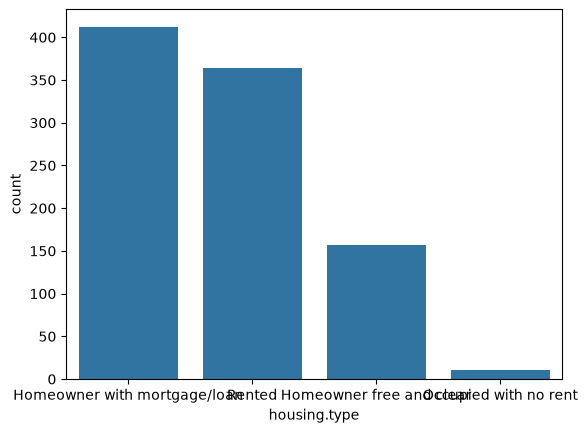

In [8]:
sns.barplot( data = housing_summary, x="housing.type", y="count")

#### Adding text wrap to make chart more readable

Text(0, 0.5, '# of Customers')

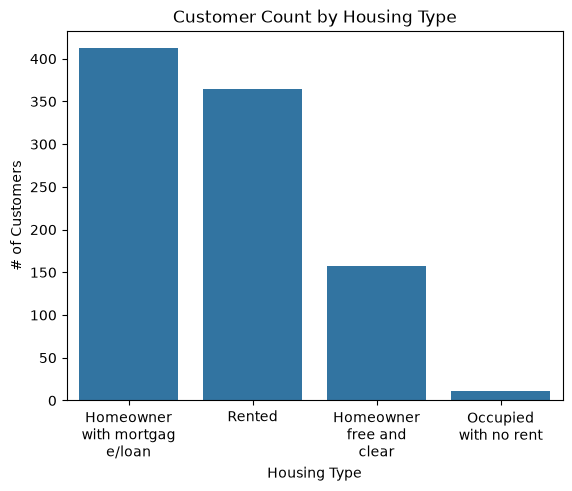

In [9]:
housing_summary["housing_summary_wrapped"] = housing_summary["housing.type"].apply(
    lambda x: textwrap.fill(str(x), width = 12)
)
sns.barplot(data=housing_summary, x="housing_summary_wrapped", y="count")
plt.title("Customer Count by Housing Type")
plt.xlabel("Housing Type")
plt.ylabel("# of Customers")

### Cleaning Summary
- Dropped 56 Rows that had N/A value in housing.type column
- Created a dataframe with housing.type and count